# Scribble Evaluation Notebook
Load a scribble from a `.npy` file (Google Drive or local path), generate conditioned photos,
compute MMD vs target distribution, and check CLIP softmax gender scores.

## 1. Setup

In [1]:
import os
import sys
from huggingface_hub import login
from google.colab import userdata
import wandb
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image

hf_token = userdata.get('HF')
if hf_token:
    login(token=hf_token)
else:
    login()

if 'google.colab' in str(get_ipython()):
    import getpass

    !pip install -q diffusers transformers accelerate xformers
    !pip install -q scikit-learn matplotlib Pillow

    github_token = userdata.get('GITHUB')
    if github_token:
        token = github_token
    else:
        token = getpass.getpass("Enter your GitHub personal access token: ")

    repo_url  = f"https://{token}@github.com/orineo1/conditional-matching-paper.git"
    repo_name = "conditional-matching-paper"
    branch    = "SD-add-vis-and-table"

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        print(f"✅ Repo '{repo_name}' already cloned — pulling latest...")
        !cd {repo_name} && git pull

    !cd {repo_name} && git checkout {branch}

    repo_path = f"/content/{repo_name}"
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    print(f"\n✅ Repo ready. Branch: {branch}")
    print(f"📁 Python path: {repo_path}")

repo_path = f"/content/{repo_name}/SD_cond_SD_controlnet"
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

wandb_token = userdata.get('WANDB')
if wandb_token:
    wandb.login(key=wandb_token)
else:
    wandb.login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 1.1 MB/s eta 0:00:00
Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 5322, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 5322 (delta 144), reused 137 (delta 80), pack-reused 5111 (from 3)
Receiving objects: 100% (5322/5322), 1.04 GiB | 75.26 MiB/s, done.
Resolving deltas: 100% (1305/1305), done.
Branch 'SD-add-vis-and-table' set up to track remote branch 'SD-add-vis-and-table' from 'origin'.
Switched to a new branch 'SD-add-vis-and-table'

✅ Repo ready. Branch: SD-add-vis-and-table
📁 Python path: /content/conditional-matching-paper


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ori-meidler (conditional-matching) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## 2. Load Scribble

In [13]:
# ── Option A: mount Google Drive ─────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# SCRIBBLE_NPY_1 = "/content/drive/MyDrive/your_folder/final_scribble_lgd_cm.npy"
# SCRIBBLE_NPY_2 = "/content/drive/MyDrive/your_folder/final_scribble_regular.npy"

# ── Option B: download from Google Drive share links ─────────────────────────
import subprocess
GDRIVE_URL_1 = "https://drive.google.com/file/d/18db4wAnld7C3YVPO9aX6h59omVi9iau1/view?usp=sharing"
GDRIVE_URL_2 = "https://drive.google.com/file/d/1ZaZECrj2CDt7Y9PDDvN7H7LkgVM8miGd/view?usp=sharing"
SCRIBBLE_NPY_1, SCRIBBLE_NPY_2 = "/tmp/scribble_1.npy", "/tmp/scribble_2.npy"

for url, path in [(GDRIVE_URL_1, SCRIBBLE_NPY_1), (GDRIVE_URL_2, SCRIBBLE_NPY_2)]:
    if not os.path.exists(path):
        subprocess.run(["pip", "install", "-q", "gdown"], check=True)
        subprocess.run(["gdown", "--fuzzy", url, "-O", path], check=True)

# ── Option C: local paths ─────────────────────────────────────────────────────
# SCRIBBLE_NPY_1 = "/path/to/final_scribble_lgd_cm.npy"
# SCRIBBLE_NPY_2 = "/path/to/final_scribble_regular.npy"

# ── Option D: upload from disk ────────────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # select two .npy files
# names = list(uploaded.keys())
# SCRIBBLE_NPY_1, SCRIBBLE_NPY_2 = names[0], names[1]

# ── Load both ─────────────────────────────────────────────────────────────────
def load_scribble(path, label):
    arr = np.load(path)
    if arr.ndim == 3:
        arr = arr[np.newaxis]
    print(f"{label}: shape={arr.shape}  dtype={arr.dtype}")
    return Image.fromarray(arr[0])

scribble_pil_1 = load_scribble(SCRIBBLE_NPY_1, "Scribble 1 (LGD-CM)")
scribble_pil_2 = load_scribble(SCRIBBLE_NPY_2, "Scribble 2 (Regular)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(scribble_pil_1); axes[0].set_title("Scribble 1 (LGD-CM)");  axes[0].axis('off')
axes[1].imshow(scribble_pil_2); axes[1].set_title("Scribble 2 (Regular)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

Scribble 1 (LGD-CM): shape=(1, 512, 512, 3)  dtype=uint8
Scribble 2 (Regular): shape=(1, 512, 512, 3)  dtype=uint8


## 3. Load Models

In [14]:
from models    import load_models
from clip_utils import load_clip_model

architect, sprinter = load_models(device)
clip_model, clip_processor = load_clip_model(device)
print("✅ Models loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Models loaded.


## 4. Build Target Distribution

In [15]:
from generation import generate_and_store_cs
from clip_utils  import encode_images_clip
from visualization import plot_row

N_TARGETS       = 100        # total target images (split evenly)
CONTROLNET_SCALE = 0.5
MAN_PROMPT   = "a superrealistic portrait photograph of a man, studio lighting"
WOMAN_PROMPT = "a superrealistic portrait photograph of a woman, studio lighting"

n_half = N_TARGETS // 2
with torch.no_grad():
    man_images,   _ = generate_and_store_cs(sprinter, MAN_PROMPT, scribble_pil_1, n_half, batch_size=2, cn_scale=CONTROLNET_SCALE)
    woman_images, _ =  generate_and_store_cs(sprinter, WOMAN_PROMPT, scribble_pil_1, n_half, batch_size=2, cn_scale=CONTROLNET_SCALE)

def pil_to_tensor(pil_list):
    return torch.cat([TF.to_tensor(img).unsqueeze(0) for img in pil_list], dim=0).to(device)

with torch.no_grad():
    all_clip_embeddings = torch.cat([
        encode_images_clip(pil_to_tensor(man_images),   clip_model, clip_processor),
        encode_images_clip(pil_to_tensor(woman_images), clip_model, clip_processor),
    ], dim=0)

print(f"Target CLIP embeddings: {all_clip_embeddings.shape}")
plot_row(man_images,   f"Target Man ({n_half})",   count=n_half)
plot_row(woman_images, f"Target Woman ({n_half})", count=n_half)

  Progress: 50/50
  Progress: 50/50
Target CLIP embeddings: torch.Size([100, 768])


## 5. Generate Eval Photos from Scribble

In [16]:
N_EVAL       = 100
EVAL_PROMPT  = "a superrealistic professional photograph of"

def generate_eval_photos(scribble_pil, n=N_EVAL):
    sprinter.vae.to(dtype=torch.float16)
    photos = []
    with torch.no_grad():
        for start in range(0, n, 2):
            bs = min(2, n - start)
            result = sprinter(
                prompt=[EVAL_PROMPT] * bs,
                image=[scribble_pil] * bs,
                num_inference_steps=2, guidance_scale=0.0,
                controlnet_conditioning_scale=CONTROLNET_SCALE, output_type="pil",
            )
            photos.extend(result.images)
    sprinter.vae.to(dtype=torch.float32)
    return photos

print("Generating photos from scribble 1 (LGD-CM)...")
eval_photos_1 = generate_eval_photos(scribble_pil_1)
print("Generating photos from scribble 2 (Regular)...")
eval_photos_2 = generate_eval_photos(scribble_pil_2)

plot_row(eval_photos_1, "Scribble 1 (LGD-CM)", count=min(10, len(eval_photos_1)))
plot_row(eval_photos_2, "Scribble 2 (Regular)", count=min(10, len(eval_photos_2)))

Generating photos from scribble 1 (LGD-CM)...
Generating photos from scribble 2 (Regular)...


## 6. Compute MMD vs Target

In [17]:
from metrics import compute_mmd

with torch.no_grad():
    eval_clip_1 = encode_images_clip(pil_to_tensor(eval_photos_1), clip_model, clip_processor)
    eval_clip_2 = encode_images_clip(pil_to_tensor(eval_photos_2), clip_model, clip_processor)

mmd_1 = compute_mmd(eval_clip_1, all_clip_embeddings).item()
mmd_2 = compute_mmd(eval_clip_2, all_clip_embeddings).item()
print(f"MMD LGD-CM  (guided)   vs target: {mmd_1:.6f}")
print(f"MMD Regular (unguided) vs target: {mmd_2:.6f}")
print(f"Delta (guided - unguided):        {mmd_1 - mmd_2:.6f}")

MMD LGD-CM  (guided)   vs target: 0.433283
MMD Regular (unguided) vs target: 0.517862
Delta (guided - unguided):        -0.084579


## 7. CLIP Softmax Gender Scores

  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
LGD-CM — Male: 22  Female: 78  MMD: 0.4333


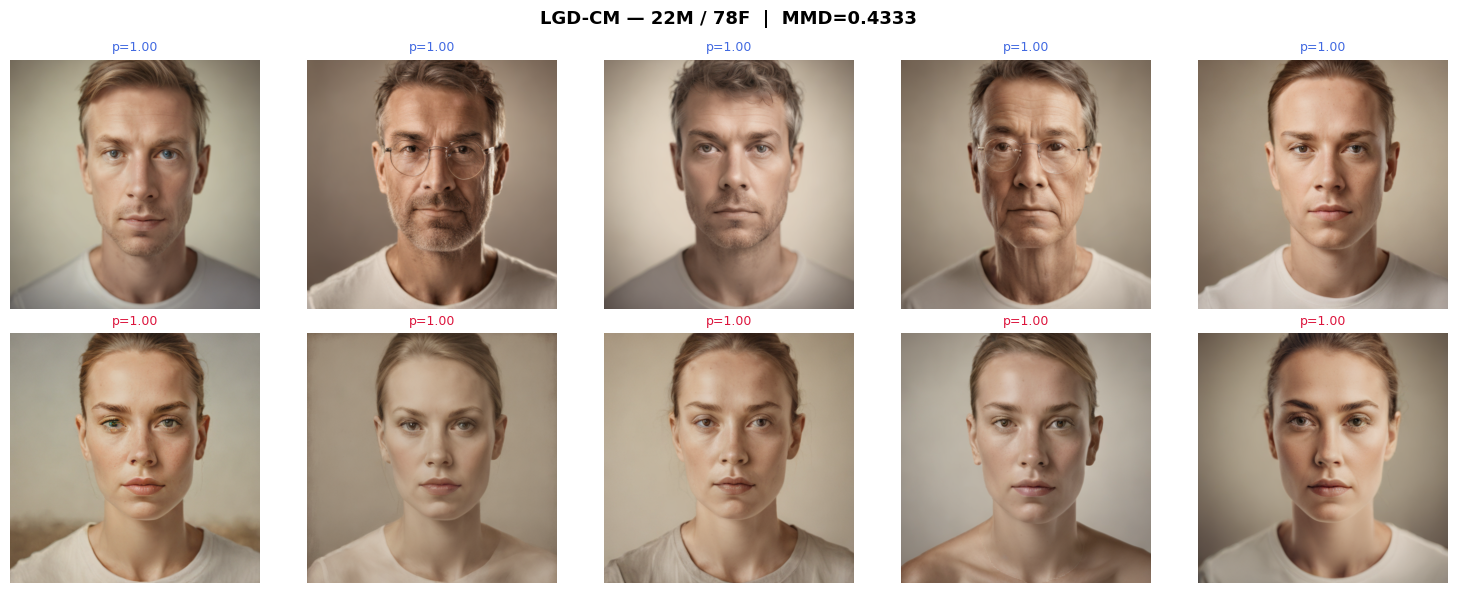

Regular — Male: 94  Female: 6  MMD: 0.5179


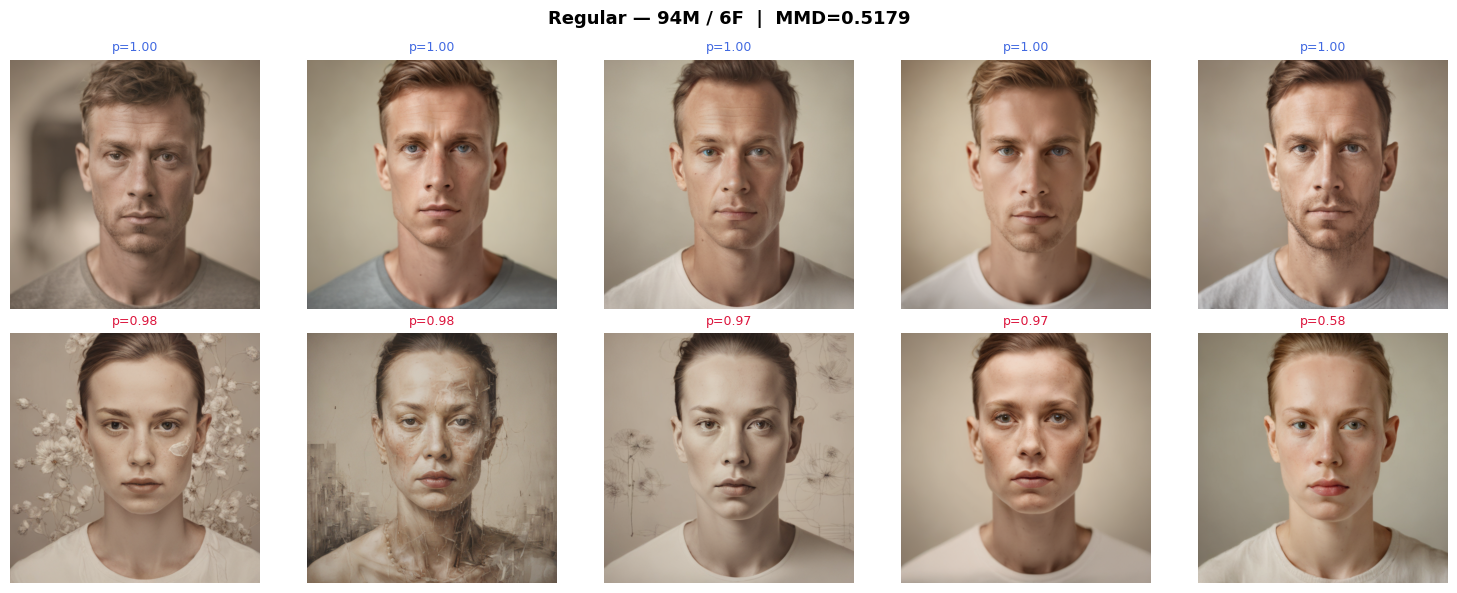

In [21]:
import torch.nn.functional as F
from run_dps import compute_clip_softmax
from metrics import compute_mmd
from IPython.display import display

results_1, eval_clip_np_1 = compute_clip_softmax(eval_photos_1, clip_model, clip_processor, MAN_PROMPT, WOMAN_PROMPT, device)
results_2, eval_clip_np_2 = compute_clip_softmax(eval_photos_2, clip_model, clip_processor, MAN_PROMPT, WOMAN_PROMPT, device)
for label, photos, results, mmd_val in [
    ("LGD-CM",  eval_photos_1, results_1, mmd_1),
    ("Regular", eval_photos_2, results_2, mmd_2),
]:
    n_male   = sum(1 for r in results if r["label"] == "male")
    n_female = sum(1 for r in results if r["label"] == "female")
    print(f"{label} — Male: {n_male}  Female: {n_female}  MMD: {mmd_val:.4f}")

    # ── Sort by confidence, split by gender ───────────────────────────
    paired = list(zip(photos, results))

    top_men = sorted(
        [(img, r) for img, r in paired if r["label"] == "male"],
        key=lambda x: x[1]["p_male"], reverse=True
    )[:5]

    top_women = sorted(
        [(img, r) for img, r in paired if r["label"] == "female"],
        key=lambda x: x[1]["p_female"], reverse=True
    )[:5]

    # ── Plot: top row = men, bottom row = women ────────────────────────
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for col, (img, r) in enumerate(top_men):
        axes[0, col].imshow(img)
        axes[0, col].set_title(f'p={r["p_male"]:.2f}', fontsize=9, color='royalblue')
        axes[0, col].axis('off')
    for col in range(len(top_men), 5):
        axes[0, col].axis('off')

    for col, (img, r) in enumerate(top_women):
        axes[1, col].imshow(img)
        axes[1, col].set_title(f'p={r["p_female"]:.2f}', fontsize=9, color='crimson')
        axes[1, col].axis('off')
    for col in range(len(top_women), 5):
        axes[1, col].axis('off')

    axes[0, 0].set_ylabel('Top 5 Men',   fontsize=11, color='royalblue', labelpad=8)
    axes[1, 0].set_ylabel('Top 5 Women', fontsize=11, color='crimson',   labelpad=8)

    fig.suptitle(
        f"{label} — {n_male}M / {n_female}F  |  MMD={mmd_val:.4f}",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    display(fig)
    plt.close()

## 8. CLIP PCA — Eval vs Target

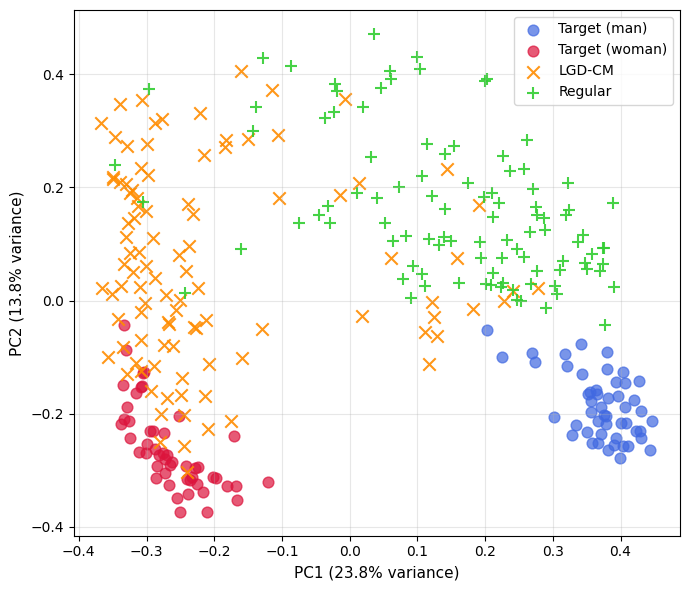

In [40]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

# ── PCA ───────────────────────────────────────────────────────────────────────
target_np = all_clip_embeddings.cpu().numpy()
combined  = np.vstack([target_np, eval_clip_np_1, eval_clip_np_2])

pca    = PCA(n_components=2)
coords = pca.fit_transform(combined)

t_man   = coords[:n_half]
t_woman = coords[n_half : 2 * n_half]
e1_pts  = coords[2 * n_half : 2 * n_half + len(eval_clip_np_1)]
e2_pts  = coords[2 * n_half + len(eval_clip_np_1):]

var1 = pca.explained_variance_ratio_[0]
var2 = pca.explained_variance_ratio_[1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(t_man[:,0],  t_man[:,1],  c='royalblue', s=60, alpha=0.7, label='Target (man)')
ax.scatter(t_woman[:,0],t_woman[:,1],c='crimson',   s=60, alpha=0.7, label='Target (woman)')
ax.scatter(e1_pts[:,0], e1_pts[:,1], c='darkorange',s=80, alpha=0.9, marker='x', label='LGD-CM')
ax.scatter(e2_pts[:,0], e2_pts[:,1], c='limegreen', s=80, alpha=0.9, marker='+', label='Regular')

ax.set_xlabel(f'PC1 ({var1:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var2:.1%} variance)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
plt.close()

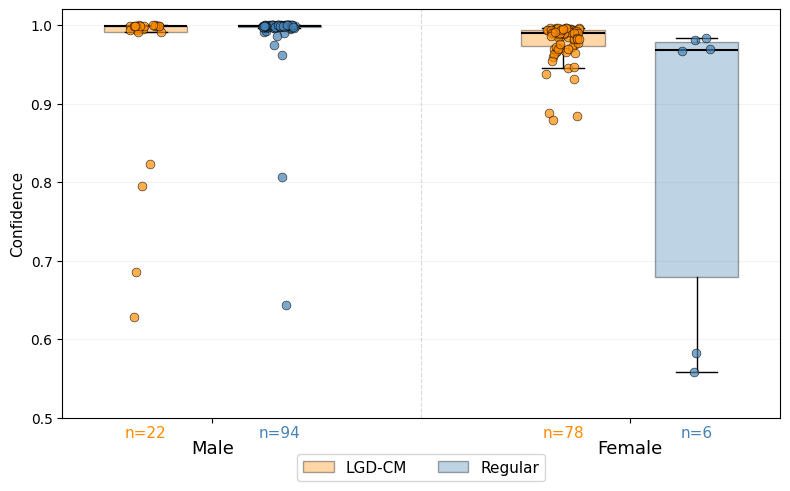

In [39]:
# ── Boxplot ───────────────────────────────────────────────────────────────────
def split_conf(results):
    return ([r["p_male"]   for r in results if r["label"] == "male"],
            [r["p_female"] for r in results if r["label"] == "female"])

m1, f1 = split_conf(results_1)
m2, f2 = split_conf(results_2)

positions = [1, 1.8, 3.5, 4.3]
data      = [m1, m2, f1, f2]
colors    = ["darkorange", "steelblue", "darkorange", "steelblue"]
counts    = [len(m1), len(m2), len(f1), len(f2)]

fig, ax = plt.subplots(figsize=(8, 5))
for pts, pos, col in zip(data, positions, colors):
    if pts:
        ax.boxplot(pts, positions=[pos], patch_artist=True, widths=0.5, showfliers=False,
                   medianprops=dict(color="black", linewidth=1.5),
                   boxprops=dict(facecolor=col, alpha=0.35, edgecolor="black"))
        jitter = np.random.uniform(-0.1, 0.1, size=len(pts))
        ax.scatter(np.full(len(pts), pos) + jitter, pts,
                   color=col, alpha=0.7, s=40, zorder=3, edgecolors="black", linewidth=0.5)

# n= labels — moved higher
for pos, count, col in zip(positions, counts, colors):
    ax.text(pos, -0.02, f"n={count}", transform=ax.get_xaxis_transform(),
            ha="center", va="top", color=col, fontsize=11, )

# Male / Female labels — moved higher
ax.set_xticks([1.4, 3.9])
ax.set_xticklabels(["Male", "Female"], fontsize=13, )
ax.tick_params(axis="x", pad=12)

ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Confidence", fontsize=11)
# ax.set_title(f"CLIP Gender Confidence — LGD-CM (MMD={mmd_1:.4f}) vs Regular (MMD={mmd_2:.4f})", fontsize=12)
ax.axvline(2.65, color="gray", lw=0.8, linestyle="--", alpha=0.3)
ax.grid(True, alpha=0.15, axis="y")

# Legend — moved higher
ax.legend(
    handles=[Patch(facecolor="darkorange", alpha=0.35, edgecolor="black", label="LGD-CM"),
             Patch(facecolor="steelblue",  alpha=0.35, edgecolor="black", label="Regular")],
    loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=2,
    frameon=True, fontsize=11,
)

plt.tight_layout()
display(fig)
plt.close()